In [2]:

import jax, os
print("jax", jax.__version__)
print("jaxlib", jax.lib.__version__)
print("JAX_PLATFORMS =", os.environ.get("JAX_PLATFORMS"))
print("LD_LIBRARY_PATH =", os.environ.get("LD_LIBRARY_PATH"))
print(jax.devices())


jax 0.6.2
jaxlib 0.6.2
JAX_PLATFORMS = None
LD_LIBRARY_PATH = None
[CudaDevice(id=0)]


In [3]:
import jax
import jax.numpy as jnp
import jax.scipy as jsp
from functools import partial

#jax.config.update("jax_enable_x64", True)

import optax
import flax.linen as nn
from flax.training.train_state import TrainState
 
import matplotlib.pyplot as plt

import sys
import json
from pathlib import Path
from toolbox import *

In [4]:
seed = 1234
key = jax.random.key(seed)
# # Forces JAX to use the asynchronous CUDA allocator, heavily reducing fragmentation
# import os
# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "cuda_async"

# Load json

In [5]:
def _strip_comment_keys(obj):
    """Recursively drop any keys that start with '//'."""
    if isinstance(obj, dict):
        return {k: _strip_comment_keys(v) for k, v in obj.items()
                if not (isinstance(k, str) and k.startswith("//"))}
    if isinstance(obj, list):
        return [_strip_comment_keys(x) for x in obj]
    return obj

def load_config_dict(config_directory: Path, filename: str = "configuration.json") -> dict:
    path = (config_directory / filename).resolve()
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    return _strip_comment_keys(data)

config_directory = Path("")
cfg = load_config_dict(config_directory, "configuration.json")

print("chi =", cfg["chi_kHz"], "kHz")
print("qubit anharmonicity =", cfg["anharmonicity_MHz"], "MHz")

# Hamiltonian parameters (MHz units)
chi = 2 * jnp.pi * cfg["chi_kHz"] * 1e-3
qubit_anham = 2 * jnp.pi * cfg["anharmonicity_MHz"]
cavity_self_kerr = 2*jnp.pi*cfg["self_Kerr_kHz"]*1e-3  # cavity self-Kerr MHz


# Relaxation times (not used in this unitary optimizer, but keep)
t1_qub = cfg["qubit_T1_us"]
t2_qub = cfg["qubit_T2_us"]
t1_cav = cfg["storage_T1_us"]

chi = 662.6902972198327 kHz
qubit anharmonicity = -164.272 MHz


## Problem parameters

#### Static constants

In [6]:
mu_qub = 20.0 #make the coeff big enough so that the amps remain betwee -2 and 2
mu_cav = 20.0

In [7]:
k = 2 #quartic bsplines (only 3 non zero bsplines simultaneously)
bspln_num = 20    # Desired number of basis pulses

# Skip exactly 'k' on both sides to use purely uniform interior splines
skip_left = k
skip_right = k
n = bspln_num + skip_left + skip_right  # Total knots required = 24


# Grid interval (delta) must be a multiple of 4ns. 
delta_ns = 64
m = n - k  # Total uniform intervals = 22

T_ns_hw = m * delta_ns
T_us_hw = T_ns_hw / 1000.0

time_start = 0.0
time_end = T_us_hw

# A degree k B-spline spans exactly k+1 intervals
L_ns = (k + 1) * delta_ns  


print("--- Pulse Properties ---")
print(f"B-spline Degree (k)     : {k}")
print(f"Grid step (delta_ns)    : {delta_ns} ns")
print(f"Single pulse length     : {L_ns} ns")
print(f"Total sequence duration : {T_ns_hw} ns ({T_us_hw} us)")
print(f"Max overlapping pulses  : {k + 1}")
print("------------------------")
assert L_ns % 4 == 0, "Pulse length is not a multiple of 4 ns!"

--- Pulse Properties ---
B-spline Degree (k)     : 2
Grid step (delta_ns)    : 64 ns
Single pulse length     : 192 ns
Total sequence duration : 1408 ns (1.408 us)
Max overlapping pulses  : 3
------------------------


In [8]:
t_drive = T_us_hw
ndt_drive = 200

num_bspln = bspln_num 
num_bspln

20

In [ ]:
inp_shape = (1,)
osz = num_bspln * 4
rec_features = osz
dense_features = [int(osz * 2), int(osz * 3), int(osz * 2)]
learning_rate=0.00001

rec_features, dense_features

(80, [160, 240, 160])

#### Dynamic const

In [10]:
N_cav = 28

t_idle = 15 #in us on average

In [11]:
psi_target_cav = basis(N_cav, 2) + basis(N_cav, 3)
psi_target_cav /= jnp.sqrt(hconj(psi_target_cav) @ psi_target_cav)

## Driven Hamiltonian

In [12]:
def build_drive_htree(N_cav, chi, e_qub, e_cav):
    a = tensor(identity(2), destroy(N_cav))
    adag = hconj(a)
    n_phot = adag @ a
    sigz = tensor(sigma.z, identity(N_cav))
    sigp = tensor(sigma.p, identity(N_cav))
    one = tensor(identity(2), identity(N_cav))

    # Dispersive shift term: (chi/2) * n * (sigma_z + I)
    H_disp = (chi / 2) * n_phot @ (one - sigz)
    
    # Cavity self-Kerr term: (K/2) * a^dag a^dag a a = (K/2) * (n^2 - n)
    H_kerr = (cavity_self_kerr / 2) * (n_phot @ n_phot - n_phot)
    # H_kerr=0.0
    
    # Combined drift Hamiltonian
    H_drift = H_disp + H_kerr
    
    ht = [
        [H_drift, 1, 1, 0],
        [mu_qub * sigp, e_qub, 1, 1],                  # Qubit plays standard I + iQ
        [mu_cav * adag, 1j * jnp.conj(e_cav), 1, 1]    # Cavity simulates the swapped I/Q cables (Q + iI)
    ]
    return ht

def get_uevol_matrix(N_cav, chi, e_qub, e_cav, dt):
    htree = build_drive_htree(N_cav, chi, e_qub, e_cav)
    hmat = hmat_from_htree(htree)
    return evol_hdt_exp(hmat, dt)

def make_drive(N_cav, chi):
    
    def drive(rho_init, es_qub, es_cav, dts):
        
        def f(rho, x):
            e_qub, e_cav, dt = x
            uevol = get_uevol_matrix(N_cav, chi, e_qub, e_cav, dt)[0]
            return uevol @ rho @ hconj(uevol), None
    
        rho_fin, _ = jax.lax.scan(f, rho_init, [es_qub, es_cav, dts])
        return rho_fin
    
    return drive

## Time-grids and B-splines

In [13]:
t_drive_edges = jnp.linspace(0, t_drive, ndt_drive + 1)
t_drive_mids = (t_drive_edges[1:] + t_drive_edges[:-1]) / 2
t_drive_intvs = t_drive_edges[1:] - t_drive_edges[:-1]

In [14]:
bspline_builder = setup_bspline_builder(0, t_drive_edges[-1], n, k, skip_left, skip_right)

bsplns_mids = bspline_builder(t_drive_mids)
bsplns_edges = bspline_builder(t_drive_edges)

knots = bknots_on_interval(0, t_drive_edges[-1], n, k)
knots = np.unique(knots)

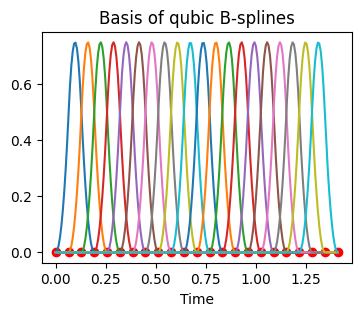

In [15]:
# TEST
fig, ax = plt.subplots(figsize=(4, 3))

for i in range(bsplns_edges.shape[0]):
    ax.plot(t_drive_edges, bsplns_edges[i])
        
ax.scatter(knots, np.zeros_like(knots), color="red");   
ax.set_xlabel("Time");
ax.set_title("Basis of qubic B-splines");
# TEST

In [16]:
def ctrl_from_coeffs(ctrl_coeffs, bsplns):
    ctrls_real = ctrl_coeffs @ bsplns
    e_qub = ctrls_real[0, ...] + 1j * ctrls_real[1, ...]
    e_cav = ctrls_real[2, ...] + 1j * ctrls_real[3, ...]
    return e_qub, e_cav

## Relaxation

In [17]:
def liouv_relax_channel(c):
    l = tensor(c, c.conj())
    l -= 1 / 2 * tensor(hconj(c) @ c, identity(len(c)))
    l -= 1 / 2 * tensor(identity(len(c)), (hconj(c) @ c).T)
    return l

def eval_idling_matrix(cs, t):
    l = sum(liouv_relax_channel(c) for c in cs)
    return jsp.linalg.expm(l * t)

def build_c_ops(N_cav, t1_qub, t2_qub, t1_cav):
    get_t_phi_qub = lambda t1, t2: 1 / ((1 / t2) - (1 / t1) / 2)
    t_phi_qub = get_t_phi_qub(t1_qub, t2_qub)

    sigm = tensor(sigma.m, identity(N_cav))
    sigz = tensor(sigma.z, identity(N_cav))
    a = tensor(identity(2), destroy(N_cav))
    
    c_ops = [
        1 / jnp.sqrt(t1_qub) * sigm,
        1 / jnp.sqrt(t_phi_qub) * sigz / jnp.sqrt(2),
        1 / jnp.sqrt(t1_cav) * a
    ]
    return c_ops

def make_idle(N_cav, t1_qub, t2_qub, t1_cav, t):
    cs = build_c_ops(N_cav, t1_qub, t2_qub, t1_cav)
    idling_matrix = eval_idling_matrix(cs, t)

    def idle(rho):
        rho_liouv = rho.reshape(-1, 1)
        rho_liouv = idling_matrix @ rho_liouv
        return rho_liouv.reshape(rho.shape)

    return idle

## Measurement with qubit reset

In [18]:
def measure_sz(key, rho_init):
    probs = rho_init.diagonal().reshape(2, -1).sum(axis=1).real
    outcome_indx = jax.random.choice(key, 2, p=probs)
    prob = probs[outcome_indx]
    
    idx_mid = rho_init.shape[-1] // 2
    rho_fin_cav = jnp.where(outcome_indx == 0, rho_init[:idx_mid, :idx_mid], rho_init[idx_mid:, idx_mid:])
    
    # Qubit rest
    rho_fin_qub = basis(2, 1) @ hconj(basis(2, 1))
    
    rho_fin = tensor(rho_fin_qub, rho_fin_cav)
    rho_fin /= jnp.trace(rho_fin)
    
    # Outcome definition
    outcome = 2 * outcome_indx - 1
    
    return outcome, prob, rho_fin

## Fidelity of the cavity state

In [19]:
def make_fidelity_cav(psi_target_cav):

    def fidelity_cav(rho):
        idx_mid = rho.shape[-1] // 2
        rho_cav = rho[:idx_mid, :idx_mid] + rho[idx_mid:, idx_mid:]
        return (hconj(psi_target_cav) @ rho_cav @ psi_target_cav)[0][0].real

    return fidelity_cav

## RNN

In [20]:
def init_carry(key, rec_features, inp_shape):
    gru_cell = nn.GRUCell(features=rec_features)
    return gru_cell.initialize_carry(key, inp_shape)

def create_flax_state(key,
                      rec_features, dense_features,
                      inp_shape, learning_rate,
                      *, print_summary):
    
    class Model(nn.Module):
    
        @nn.compact
        def __call__(self, carry, x):
            
            gru_cell = nn.GRUCell(features=rec_features)
            carry, x = gru_cell(carry, x)
            
            for ndf in dense_features:
                x = nn.Dense(ndf)(x)
                x = jax.nn.relu(x)
                
            out_layer = nn.Dense(4 * num_bspln)
            x = out_layer(x)
            x = x.reshape(4, num_bspln)
            
            return carry, x

    model = Model()

    fake_key = jax.random.key(0)
    fake_carry = init_carry(fake_key, rec_features, inp_shape)
    fake_inp = jnp.ones(inp_shape)
    params = model.init(key, fake_carry, fake_inp)["params"]

    optimizer = optax.adam(learning_rate=learning_rate)

    flax_state = TrainState.create(apply_fn=model.apply, params=params, tx=optimizer)

    if print_summary:
        print(model.tabulate(fake_key, fake_carry, fake_inp))

    return flax_state

def apply_nn(flax_state, params, carry, inp):
    return flax_state.apply_fn({'params': params}, carry, inp)



In [21]:
key, subkey = jax.random.split(key)
flax_state = create_flax_state(
    subkey, rec_features, dense_features, inp_shape, learning_rate,
    print_summary=True
)


                                 Model Summary                                  
┏━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ path         ┃ module  ┃ inputs        ┃ outputs         ┃ params            ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│              │ Model   │ - float32[80] │ - float32[80]   │                   │
│              │         │ - float32[1]  │ - float32[4,20] │                   │
├──────────────┼─────────┼───────────────┼─────────────────┼───────────────────┤
│ GRUCell_0    │ GRUCell │ - float32[80] │ - float32[80]   │                   │
│              │         │ - float32[1]  │ - float32[80]   │                   │
├──────────────┼─────────┼───────────────┼─────────────────┼───────────────────┤
│ GRUCell_0/ir │ Dense   │ float32[1]    │ float32[80]     │ bias: float32[80] │
│              │         │               │                 │ kernel:           │
│              │         │ 

## Time step  
- 1) Measurement
- 2) Fidelity
- 3) Idling (decay)
- 3) RNN interrogation
- 3) Qubit reset

In [22]:
def make_time_step(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav):
    fidelity_cav = make_fidelity_cav(psi_target_cav)
    idle = make_idle(N_cav, t1_qub, t2_qub, t1_cav, t_idle)
    drive = make_drive(N_cav, chi)
    
    def time_step(key, rho, flax_state, params, carry):
        meas_out, prob, rho = measure_sz(key, rho)
        fid = fidelity_cav(rho)
        rho = idle(rho)
        rnn_inp = jnp.array([meas_out], dtype=float)
        carry, ctrl_coeffs = apply_nn(flax_state, params, carry, rnn_inp)
        es_qub, es_cav = ctrl_from_coeffs(ctrl_coeffs, bsplns_mids)
        rho = drive(rho, es_qub, es_cav, t_drive_intvs)  
        return rho, carry, fid, meas_out, prob
    
    return time_step

## Trajectory

In [23]:
def make_trajectory(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav):
    time_step = make_time_step(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav)
    
    def trajectory(key, flax_state, params, num_time_steps):
        
        def f(scan_carry, _):
            key, rho, carry = scan_carry
            key, subkey = jax.random.split(key)
            rho, carry, fid, meas_out, prob = time_step(subkey, rho, flax_state, params, carry)
            y = fid, meas_out, prob
            scan_carry = key, rho, carry
            return scan_carry, y
        
        key1, key2 = jax.random.split(key)
        carry = init_carry(key1, rec_features, inp_shape)
        psi_init = tensor(basis(2, 1), psi_target_cav)
        scan_carry = key2, psi_init @ hconj(psi_init), carry
        _, ys = jax.lax.scan(f, scan_carry, length=num_time_steps)
        return ys
    
    return trajectory

## Trajectory with reward gradients

In [24]:
def make_trajectory_with_rewgrad(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav):
    
    trajectory = make_trajectory(N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav)
    
    def trajectory_with_rewgrad(key, flax_state, num_time_steps):
    
        def func(params):
            traj_out = trajectory(key, flax_state, params, num_time_steps)
            fid, meas_out, prob = traj_out
            rew = -jnp.log(1 - fid.mean())
            log_prob = jnp.log(prob).sum()
            return rew + jax.lax.stop_gradient(rew) * log_prob, traj_out
    
        grad_func = jax.grad(func, has_aux=True)
        rewgrad, traj_out = grad_func(flax_state.params)
        return rewgrad, traj_out
    
    return trajectory_with_rewgrad

## Train on batch

In [25]:
def make_train_on_batch(
        N_cav, chi,
        t1_qub, t2_qub, t1_cav, t_idle,
        psi_target_cav,
        batch_size, num_time_steps
    ):
    
    trajectory_with_rewgrad = make_trajectory_with_rewgrad(
        N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav
    )
    
    trajectory_with_rewgrad_vec = jax.vmap(
            trajectory_with_rewgrad, in_axes=(0, None, None)
        )
    
    @jax.jit
    def train_on_batch(key, flax_state):
        keys = jax.random.split(key, batch_size)
        rewgrad, traj_out = trajectory_with_rewgrad_vec(keys, flax_state, num_time_steps)
        lossgrad = jax.tree.map(lambda x: -x.mean(axis=0), rewgrad)
        flax_state = flax_state.apply_gradients(grads=lossgrad) 
        return flax_state, traj_out
    
    return train_on_batch

In [26]:
# def make_train_on_batch(
#         N_cav, chi,
#         t1_qub, t2_qub, t1_cav, t_idle,
#         psi_target_cav,
#         batch_size, num_time_steps
#     ):
    
#     trajectory_with_rewgrad = make_trajectory_with_rewgrad(
#         N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav
#     )
    
#     trajectory_with_rewgrad_vec = jax.vmap(
#             trajectory_with_rewgrad, in_axes=(0, None, None)
#         )
    
#     micro_batch_size = 8  
#     num_micro_batches = batch_size // micro_batch_size
    
#     @jax.jit
#     def train_on_batch(key, flax_state):
#         keys = jax.random.split(key, batch_size)
        
#         # --- FIXED RESHAPE LINE ---
#         keys_chunked = keys.reshape((num_micro_batches, micro_batch_size) + keys.shape[1:])
#         # --------------------------
        
#         def micro_step_fn(grad_accumulator, current_keys):
#             rewgrad, traj_out = trajectory_with_rewgrad_vec(current_keys, flax_state, num_time_steps)
            
#             lossgrad = jax.tree.map(lambda x: -x.mean(axis=0) / num_micro_batches, rewgrad)
#             grad_accumulator = jax.tree.map(lambda acc, g: acc + g, grad_accumulator, lossgrad)
            
#             return grad_accumulator, traj_out
        
#         init_grads = jax.tree.map(lambda x: jnp.zeros_like(x), flax_state.params)
        
#         final_grads, all_traj_outs = jax.lax.scan(micro_step_fn, init_grads, keys_chunked)
#         flax_state = flax_state.apply_gradients(grads=final_grads) 
        
#         return flax_state, all_traj_outs
    
#     return train_on_batch

## Test on batch

In [27]:
def make_test_on_batch(
        N_cav, chi,
        t1_qub, t2_qub, t1_cav, t_idle,
        psi_target_cav,
        batch_size, num_time_steps
    ):
    
    trajectory = make_trajectory(
        N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav
    )
    
    trajectory_vec = jax.vmap(
            trajectory, in_axes=(0, None, None, None)
        )
    
    @jax.jit
    def test_on_batch(key, flax_state):
        keys = jax.random.split(key, batch_size)
        traj_out = trajectory_vec(keys, flax_state, flax_state.params, num_time_steps)
        return traj_out
    
    return test_on_batch

## >>> Run

In [28]:
mean_fids_train = []

In [29]:
num_time_steps_train = 16
num_time_steps_test = 150
batch_size = 32

In [30]:
train_on_batch = make_train_on_batch(
    N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav, batch_size, num_time_steps_train)

test_on_batch = make_test_on_batch(
    N_cav, chi, t1_qub, t2_qub, t1_cav, t_idle, psi_target_cav, batch_size, num_time_steps_test)

In [ ]:
for i in range(3000):
    key, subkey = jax.random.split(key)
    flax_state, traj_out = train_on_batch(subkey, flax_state)
    fids, meas_outs, probs = traj_out
    mean_fid = fids.mean()
    mean_fids_train.append(mean_fid)

    print("i =",i,"    fid =",mean_fid)

i = 0     fid = 0.9347628
i = 1     fid = 0.9546762
i = 2     fid = 0.9505627
i = 3     fid = 0.93916094
i = 4     fid = 0.9466073
i = 5     fid = 0.94449127
i = 6     fid = 0.95154893
i = 7     fid = 0.9378085
i = 8     fid = 0.93707544
i = 9     fid = 0.9567284
i = 10     fid = 0.9357728
i = 11     fid = 0.9337405
i = 12     fid = 0.9293588
i = 13     fid = 0.9462934


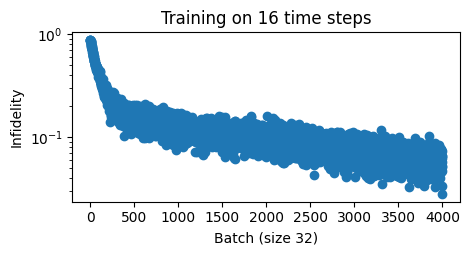

In [36]:
fig, ax = plt.subplots(figsize=(5, 2.2))

ff = jnp.array(mean_fids_train)

ax.scatter(jnp.arange(len(mean_fids_train)), 1 - ff);
ax.set_xlabel(f"Batch (size {batch_size})");
ax.set_ylabel("Infidelity");
ax.set_title(f"Training on {num_time_steps_train} time steps");
ax.set_yscale("log");

#fig.savefig("train.pdf", bbox_inches="tight");

In [37]:
save_flax_state("trained_nn15_20bs_2_plus_3", flax_state)


In [38]:
#save it in c++ compatible format in the save folder
import struct

def save_cpp_weights(fld, state):
    abs_path = os.path.abspath(fld)
    out_file = os.path.join(abs_path, "weights.bin")

    p = state.params

    arrays = [
        np.asarray(p["GRUCell_0"]["ir"]["kernel"], dtype=np.float32),
        np.asarray(p["GRUCell_0"]["ir"]["bias"], dtype=np.float32),
        np.asarray(p["GRUCell_0"]["hr"]["kernel"], dtype=np.float32),

        np.asarray(p["GRUCell_0"]["iz"]["kernel"], dtype=np.float32),
        np.asarray(p["GRUCell_0"]["iz"]["bias"], dtype=np.float32),
        np.asarray(p["GRUCell_0"]["hz"]["kernel"], dtype=np.float32),

        np.asarray(p["GRUCell_0"]["in"]["kernel"], dtype=np.float32),
        np.asarray(p["GRUCell_0"]["in"]["bias"], dtype=np.float32),
        np.asarray(p["GRUCell_0"]["hn"]["kernel"], dtype=np.float32),

        np.asarray(p["Dense_0"]["kernel"], dtype=np.float32),
        np.asarray(p["Dense_0"]["bias"], dtype=np.float32),

        np.asarray(p["Dense_1"]["kernel"], dtype=np.float32),
        np.asarray(p["Dense_1"]["bias"], dtype=np.float32),

        np.asarray(p["Dense_2"]["kernel"], dtype=np.float32),
        np.asarray(p["Dense_2"]["bias"], dtype=np.float32),

        np.asarray(p["Dense_3"]["kernel"], dtype=np.float32),
        np.asarray(p["Dense_3"]["bias"], dtype=np.float32),
    ]

    with open(out_file, "wb") as f:
        f.write(b"GRUCPP01")
        f.write(struct.pack("i", len(arrays)))

        for a in arrays:
            a = np.ascontiguousarray(a)
            f.write(struct.pack("i", a.ndim))
            for s in a.shape:
                f.write(struct.pack("i", s))
            f.write(a.tobytes())

    print(f"Saved C++ weights to {out_file}")


save_cpp_weights("trained_nn15_20bs_2_plus_3", flax_state)

Saved C++ weights to /home/user/python_experiments/train_feedback_grape/trained_nn15_20bs_2_plus_3/weights.bin


In [ ]:
key, subkey = jax.random.split(key)
traj_out = test_on_batch(subkey, flax_state)
fids, meas_outs, probs = traj_out

In [ ]:
test_indx = [0, 1, 2]

fig, axes = plt.subplots(len(test_indx), 1, figsize=(7, 1.7 * len(test_indx)), sharex=True, sharey=True)

for ax, ti in zip(axes, test_indx):
    f = fids[ti]
    m = meas_outs[ti]
    arng = jnp.arange(len(f))
    ax.scatter(arng[m==1], f[m==1], label=r"Measured $+1$");
    ax.scatter(arng[m==-1], f[m==-1], label=r"Measured $-1$");
    ax.set_ylabel("Fidelity");
    
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.35),
          fancybox=True, shadow=True, ncol=5);
ax.set_xlabel("Time step");
ax.set_title("");

#fig.savefig("stabilize.pdf", bbox_inches="tight");

In [ ]:
idle = make_idle(N_cav, t1_qub, t2_qub, t1_cav, t_idle)
fidelity_cav = make_fidelity_cav(psi_target_cav)

psi_init = tensor(basis(2, 1), psi_target_cav)
rho_init = psi_init @ hconj(psi_init)

In [ ]:
rho = rho_init
fids_nostab = []

for i in range(num_time_steps_test):
    rho = idle(rho)
    f = fidelity_cav(rho)
    fids_nostab.append(f)
    
fids_nostab = jnp.array(fids_nostab)

In [ ]:
fig, ax = plt.subplots(figsize=(5.3, 2.2))
ax.scatter(jnp.arange(len(fids_nostab)), fids_nostab);
ax.set_yscale("log");
ax.set_ylabel("Fidelity");
ax.set_xlabel("Time step");
ax.set_title("Decay without control");

#fig.savefig("noctrl.pdf", bbox_inches="tight");

In [ ]:
fids_nostab